# 1. Load Dynamo & Data

In [424]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn

dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')
dyn.get_all_dependencies_version()

%load_ext autoreload
%autoreload 2

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf
Registered custom font as: Arial


package,ipykernel,numpy,setuptools,Pygments,igraph,datacache,tqdm,pynndescent,adjustText,networkx,umap-learn,pandas,get_version,mudata,dynamo-release,patsy,colorcet,numpy,numba,loompy,scikit-learn,seaborn,leidenalg,openpyxl,statsmodels,anndata,matplotlib,numdifftools,scipy,requests
version,6.30.1,2.0.2,80.9.0,2.19.1,1.0.0,1.4.1,4.67.3,0.6.0,1.3.0,3.2.1,0.5.11,2.3.3,3.5.5,0.2.4,1.5.2,1.0.2,3.1.0,2.0.2,0.60.0,3.0.8,1.6.1,0.13.2,0.11.0,3.1.5,0.14.6,0.10.9,3.9.4,0.9.41,1.13.1,2.32.5


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [415]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [550]:
adata = sc.read_mtx("/Users/marikaabe/Desktop/ancestors/GSE239410/GSE239410_muti_omic_injury_snRNAseq_mat.mtx.gz").T
adata

AnnData object with n_obs × n_vars = 137490 × 32520

In [495]:
# Import AnnData with cell by gene matrix
cont_full=dyn.read('SRX21172619.h5ad')
cont_full

AnnData object with n_obs × n_vars = 16064 × 25593
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'ambiguous', 'spliced', 'unspliced'

In [515]:
#GSE239410 snRNAseq cell file to obtain celltype annotations
cells = pd.read_csv("/Users/marikaabe/Desktop/ancestors/GSE239410/GSE239410_muti_omic_injury_snRNAseq_mat_cells.txt.gz", sep='\t')
cells

,cell_id,celltype,UMAP_1,UMAP_2
0,Control_2_AAACAGCCAATAACGA-1,Rod,9.386673,-6.210028
1,Control_2_AAACAGCCAATGAATG-1,AC,-4.355316,-9.826273
2,Control_2_AAACAGCCAATGCCTA-1,Cone,8.626195,9.797746
3,Control_2_AAACAGCCACCAGCAT-1,Rod,10.381906,-4.222600
4,Control_2_AAACAGCCAGGATGGC-1,AC,-8.371122,-5.765448
...,...,...,...,...
137485,NMDA_96hr_TTTGTTGGTCACAAAT-1,BC,-1.844117,8.206135
137486,NMDA_96hr_TTTGTTGGTCCCGAAG-1,RestMG,2.553883,-4.501676
137487,NMDA_96hr_TTTGTTGGTGGTTAGC-1,AC,-4.792295,-9.268966
137488,NMDA_96hr_TTTGTTGGTGTAACCA-1,Cone,5.745802,7.606577


In [516]:
# Add celltype annotations
cells_cont = cells[cells["cell_id"].str.startswith("Control_2_")]
cells_cont["cell_id"] = cells_cont["cell_id"].str.split("_|-").str[2]
cells_cont.set_index("cell_id", inplace=True)
cont = cont_full[cont_full.obs.index.isin(cells_cont.index)].copy()
cont.obs["cell_type"] = cont.obs.index.map(cells_cont["celltype"])
cont.obs

,gene_count_spliced,umi_count_spliced,gene_count_ambiguous,umi_count_ambiguous,gene_count_unspliced,umi_count_unspliced,SRX_accession,cell_type,cell_ontology_term_id
AAAGGAGCATTAGCGC,539,639.0,12,14.0,1298,2271.0,SRX21172619,AC,
AACCCGCAGAGAGCCG,408,552.0,14,14.0,733,1209.0,SRX21172619,Cone,
AACCCGCAGCTCCCTG,706,917.0,19,22.0,1080,2028.0,SRX21172619,BC,
AACCTAATCATTCATC,480,569.0,17,19.0,909,1669.0,SRX21172619,HC,
AACCTAATCGAGGTGG,573,738.0,14,18.0,792,1308.0,SRX21172619,BC,
...,...,...,...,...,...,...,...,...,...
TTTATGGAGTCGCAAT,1373,1969.0,36,49.0,2582,6304.0,SRX21172619,BC,
TTTGACTTCCGTAAAC,444,568.0,15,19.0,719,1164.0,SRX21172619,AC,
TTTGCATTCCCGCCTA,536,648.0,20,20.0,1184,2756.0,SRX21172619,Rod,
TTTGTCCCATCCCGCT,537,646.0,17,18.0,743,1289.0,SRX21172619,Rod,


In [538]:
nmda_full =dyn.read('SRX21788830.h5ad') # 96hr
nmda_full

AnnData object with n_obs × n_vars = 28182 × 25593
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'

In [540]:
adata =dyn.read('SRX23456399.h5ad') # 36 hr
adata

AnnData object with n_obs × n_vars = 29896 × 25593
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'ambiguous', 'spliced', 'unspliced'

In [547]:
adata =dyn.read('SRX21788827.h5ad') # 72 hr
adata

AnnData object with n_obs × n_vars = 27622 × 25593
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'ambiguous', 'spliced', 'unspliced'

In [546]:
cells["cell_id"].str.split("_").str[:2].str.join("_").unique()

array(['Control_2', 'LD_14D', 'LD_36hr', 'LD_54hr', 'LD_72hr', 'LD_7D',
       'LD_96hr', 'NMDA_14D', 'NMDA_36hr', 'NMDA_54hr', 'NMDA_72hr',
       'NMDA_7D', 'NMDA_96hr'], dtype=object)

In [548]:
cells[cells["cell_id"].str.startswith("NMDA_72hr_")]

,cell_id,celltype,UMAP_1,UMAP_2
105289,NMDA_72hr_AAACAGCCACCCACAG-1,AC,-3.429722,-10.455598
105290,NMDA_72hr_AAACAGCCACCTCACC-1,Rod,10.399278,-3.103340
105291,NMDA_72hr_AAACAGCCAGAATGAC-1,Rod,9.268095,-5.271360
105292,NMDA_72hr_AAACAGCCATAGACCC-1,RestMG,2.346999,-6.175380
105293,NMDA_72hr_AAACATGCAACTAACT-1,Rod,7.030177,-5.908662
...,...,...,...,...
116603,NMDA_72hr_TTTGTTGGTAAGCTTG-1,ActivateMG,-0.488519,0.909613
116604,NMDA_72hr_TTTGTTGGTATCTGGA-1,BC,-8.017014,5.638283
116605,NMDA_72hr_TTTGTTGGTGCTCCAC-1,Cone,5.965208,7.563549
116606,NMDA_72hr_TTTGTTGGTTCCGGGA-1,Rod,8.051237,-3.140301


In [549]:
# Extract cell ID and celltype annotations
cells_nmda = cells[cells["cell_id"].str.startswith("NMDA_72hr_")]
cells_nmda["cell_id"] = cells_nmda["cell_id"].str.split("_|-").str[2]
cells_nmda.set_index("cell_id", inplace=True)
nmda = nmda_full[nmda_full.obs.index.isin(cells_nmda.index)].copy()
nmda.obs["cell_type"] = nmda.obs.index.map(cells_nmda["celltype"])

# Change var index to match Dynamo format
nmda.var.set_index(nmda.var["gene_symbols"].astype(str), inplace=True) 

nmda.obs

,gene_count_Unique,umi_count_Unique,gene_count_UniqueAndMult-EM,umi_count_UniqueAndMult-EM,gene_count_UniqueAndMult-Uniform,umi_count_UniqueAndMult-Uniform,SRX_accession,cell_type,cell_ontology_term_id
AAACCGAAGCATTAGC,519,653.0,525,664.000061,536,663.999756,SRX21788830,Cone,
AAACGGATCCTTTACG,633,1021.0,649,1025.999756,650,1025.999756,SRX21788830,Cone,
AAAGCTTGTGCTGGTG,863,1336.0,897,1349.999512,899,1349.999512,SRX21788830,BC,
AAAGGAGCATTGCGTA,370,563.0,374,565.000000,374,565.000000,SRX21788830,AC,
AACAGCAAGCGGCTGT,654,875.0,677,888.999756,684,888.999695,SRX21788830,AC,
...,...,...,...,...,...,...,...,...,...
TTTCCACCAGCACCAT,2058,3864.0,2095,3895.000000,2122,3895.000244,SRX21788830,Cone,
TTTGCATTCCTGATTT,450,588.0,457,596.000000,472,596.000183,SRX21788830,AC,
TTTGCGACAGTTTGGC,897,1431.0,916,1444.000000,936,1443.999756,SRX21788830,Cone,
TTTGTCCCAAACGGGC,649,875.0,660,886.999939,687,886.999756,SRX21788830,HC,


In [530]:
# Extract cell ID and celltype annotations
cells_nmda = cells[cells["cell_id"].str.startswith("NMDA_96hr_")]
cells_nmda["cell_id"] = cells_nmda["cell_id"].str.split("_|-").str[2]
cells_nmda.set_index("cell_id", inplace=True)
nmda = nmda_full[nmda_full.obs.index.isin(cells_nmda.index)].copy()
nmda.obs["cell_type"] = nmda.obs.index.map(cells_nmda["celltype"])
nmda.obs

# Change layer names to match Dynamo format
nmda.layers['spliced'] = nmda.layers['UniqueAndMult-EM']
nmda.layers['unspliced'] = nmda.layers['unspliced']

# Change var index to match Dynamo format
nmda.var.set_index(nmda.var["gene_symbols"].astype(str), inplace=True) 

# 2. Preprocessing

In [531]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
preprocessor.preprocess_adata(nmda, recipe='monocle')

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----? No layers exist in adata, skipp filtering by shared counts
|-----------> filtered out 16053 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [22.9533s]
|-----> [Cell Cycle Scores Estimation] completed [0.8268s]
|-----> [Preprocessor-monocle] completed [2.1337s]

╭─ SUMMARY: Preprocessor.preprocess_adata ───────────────────────────╮
│  Duration: 2.1354s                                                 │
│  Shape:    9,919 x 25,593 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ Size_Factor (float)                                  │
│           │ ✚ Un

# 3. Velocity

In [537]:
nmda.layers

Layers with keys: UniqueAndMult-EM, UniqueAndMult-Uniform, X_UniqueAndMult-Uniform, X_UniqueAndMult-EM

In [533]:
dyn.tl.moments(nmda)

|-----> calculating first/second moments...
|-----? layer X_UniqueAndMult-Uniform is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_UniqueAndMult-EM is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----> [moments calculation] completed [8.9026s]

╭─ SUMMARY: moments ─────────────────────────────────────────────────╮
│  Duration: 8.9075s                                                 │
│  Shape:    9,919 x 25,593 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


In [534]:
dyn.tl.dynamics(nmda, model='stochastic', cores=10)

|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----? layer X_UniqueAndMult-Uniform is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_UniqueAndMult-EM is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----> [moments calculation] completed [8.7637s]

╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 8.8651s                                                 │
│  Shape:    9,919 x 25,593 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ───────────

KeyError: 'M_us'

|-----------> plotting with basis key=X_tsne
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


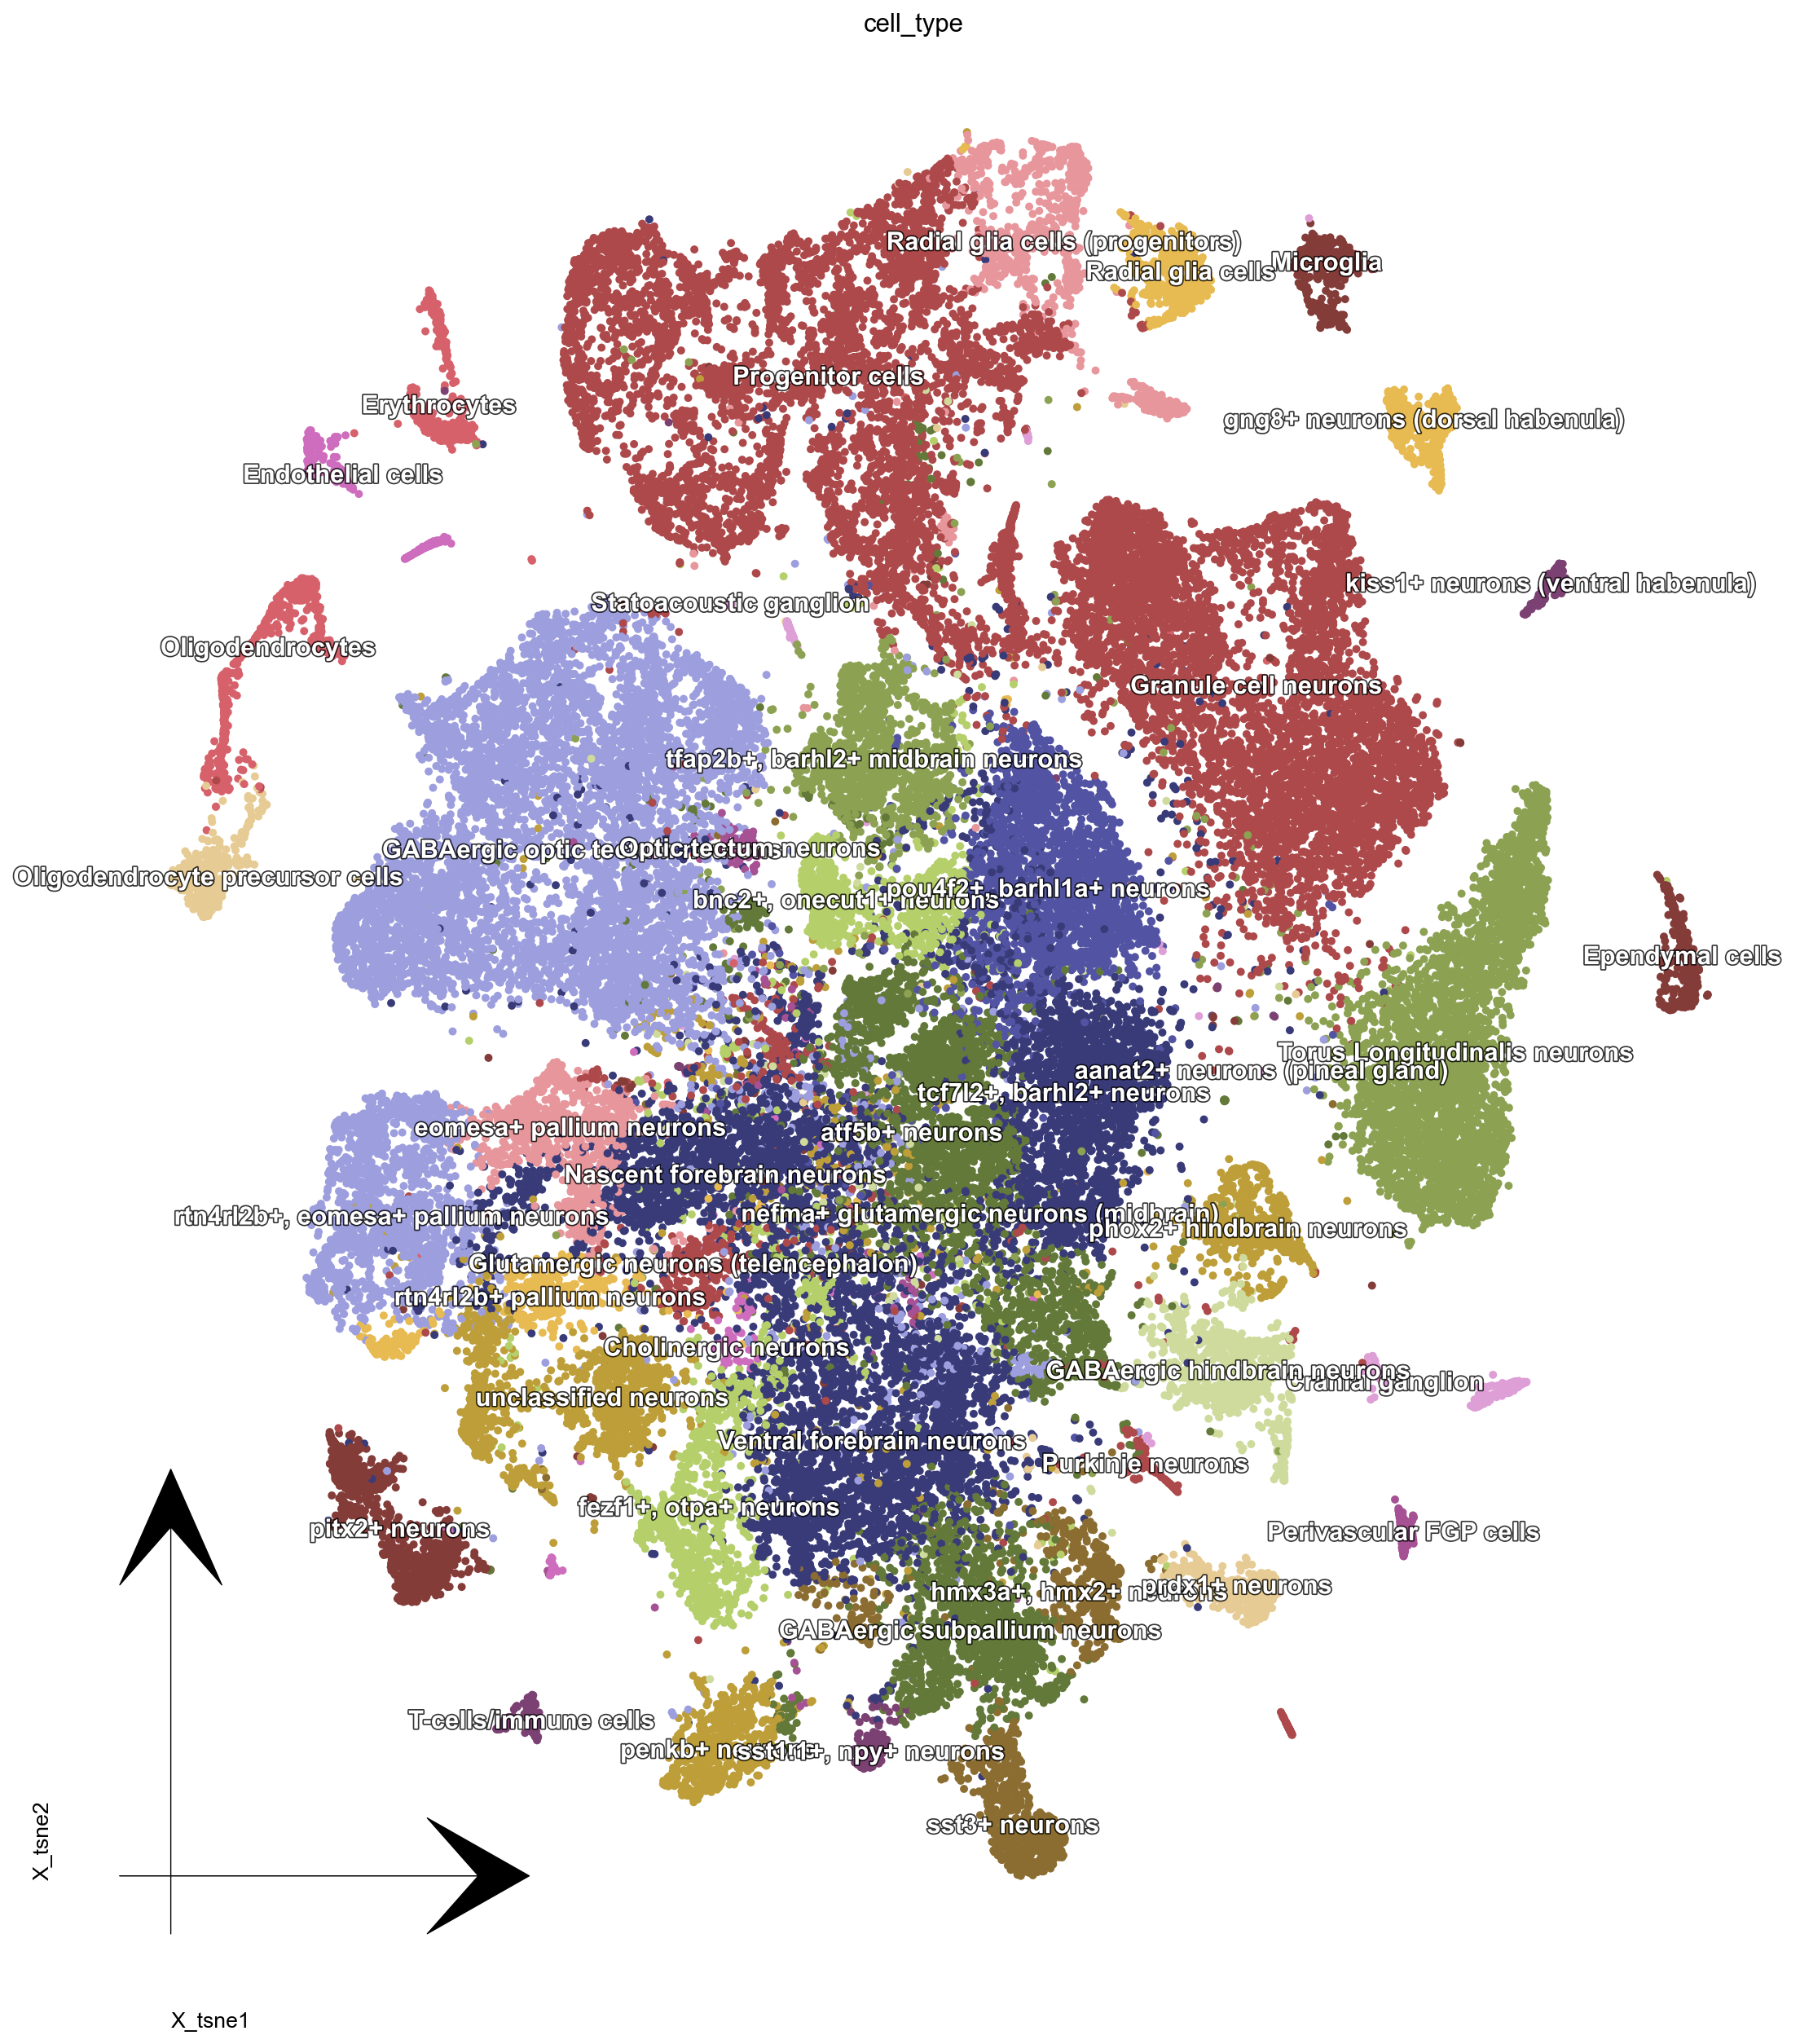

In [420]:
dyn.pl.tsne(adata, 
            color='cell_type', 
            color_key = color_key,
            figsize=(20,20),
            pointsize=0.3,
            alpha=1)

In [421]:
adata.write_h5ad('adata_temp.h5ad')

|-----------> plotting with basis key=X_tsne
|-----------> skip filtering lineage_cells by stack threshold when stacking color because it is not a numeric type


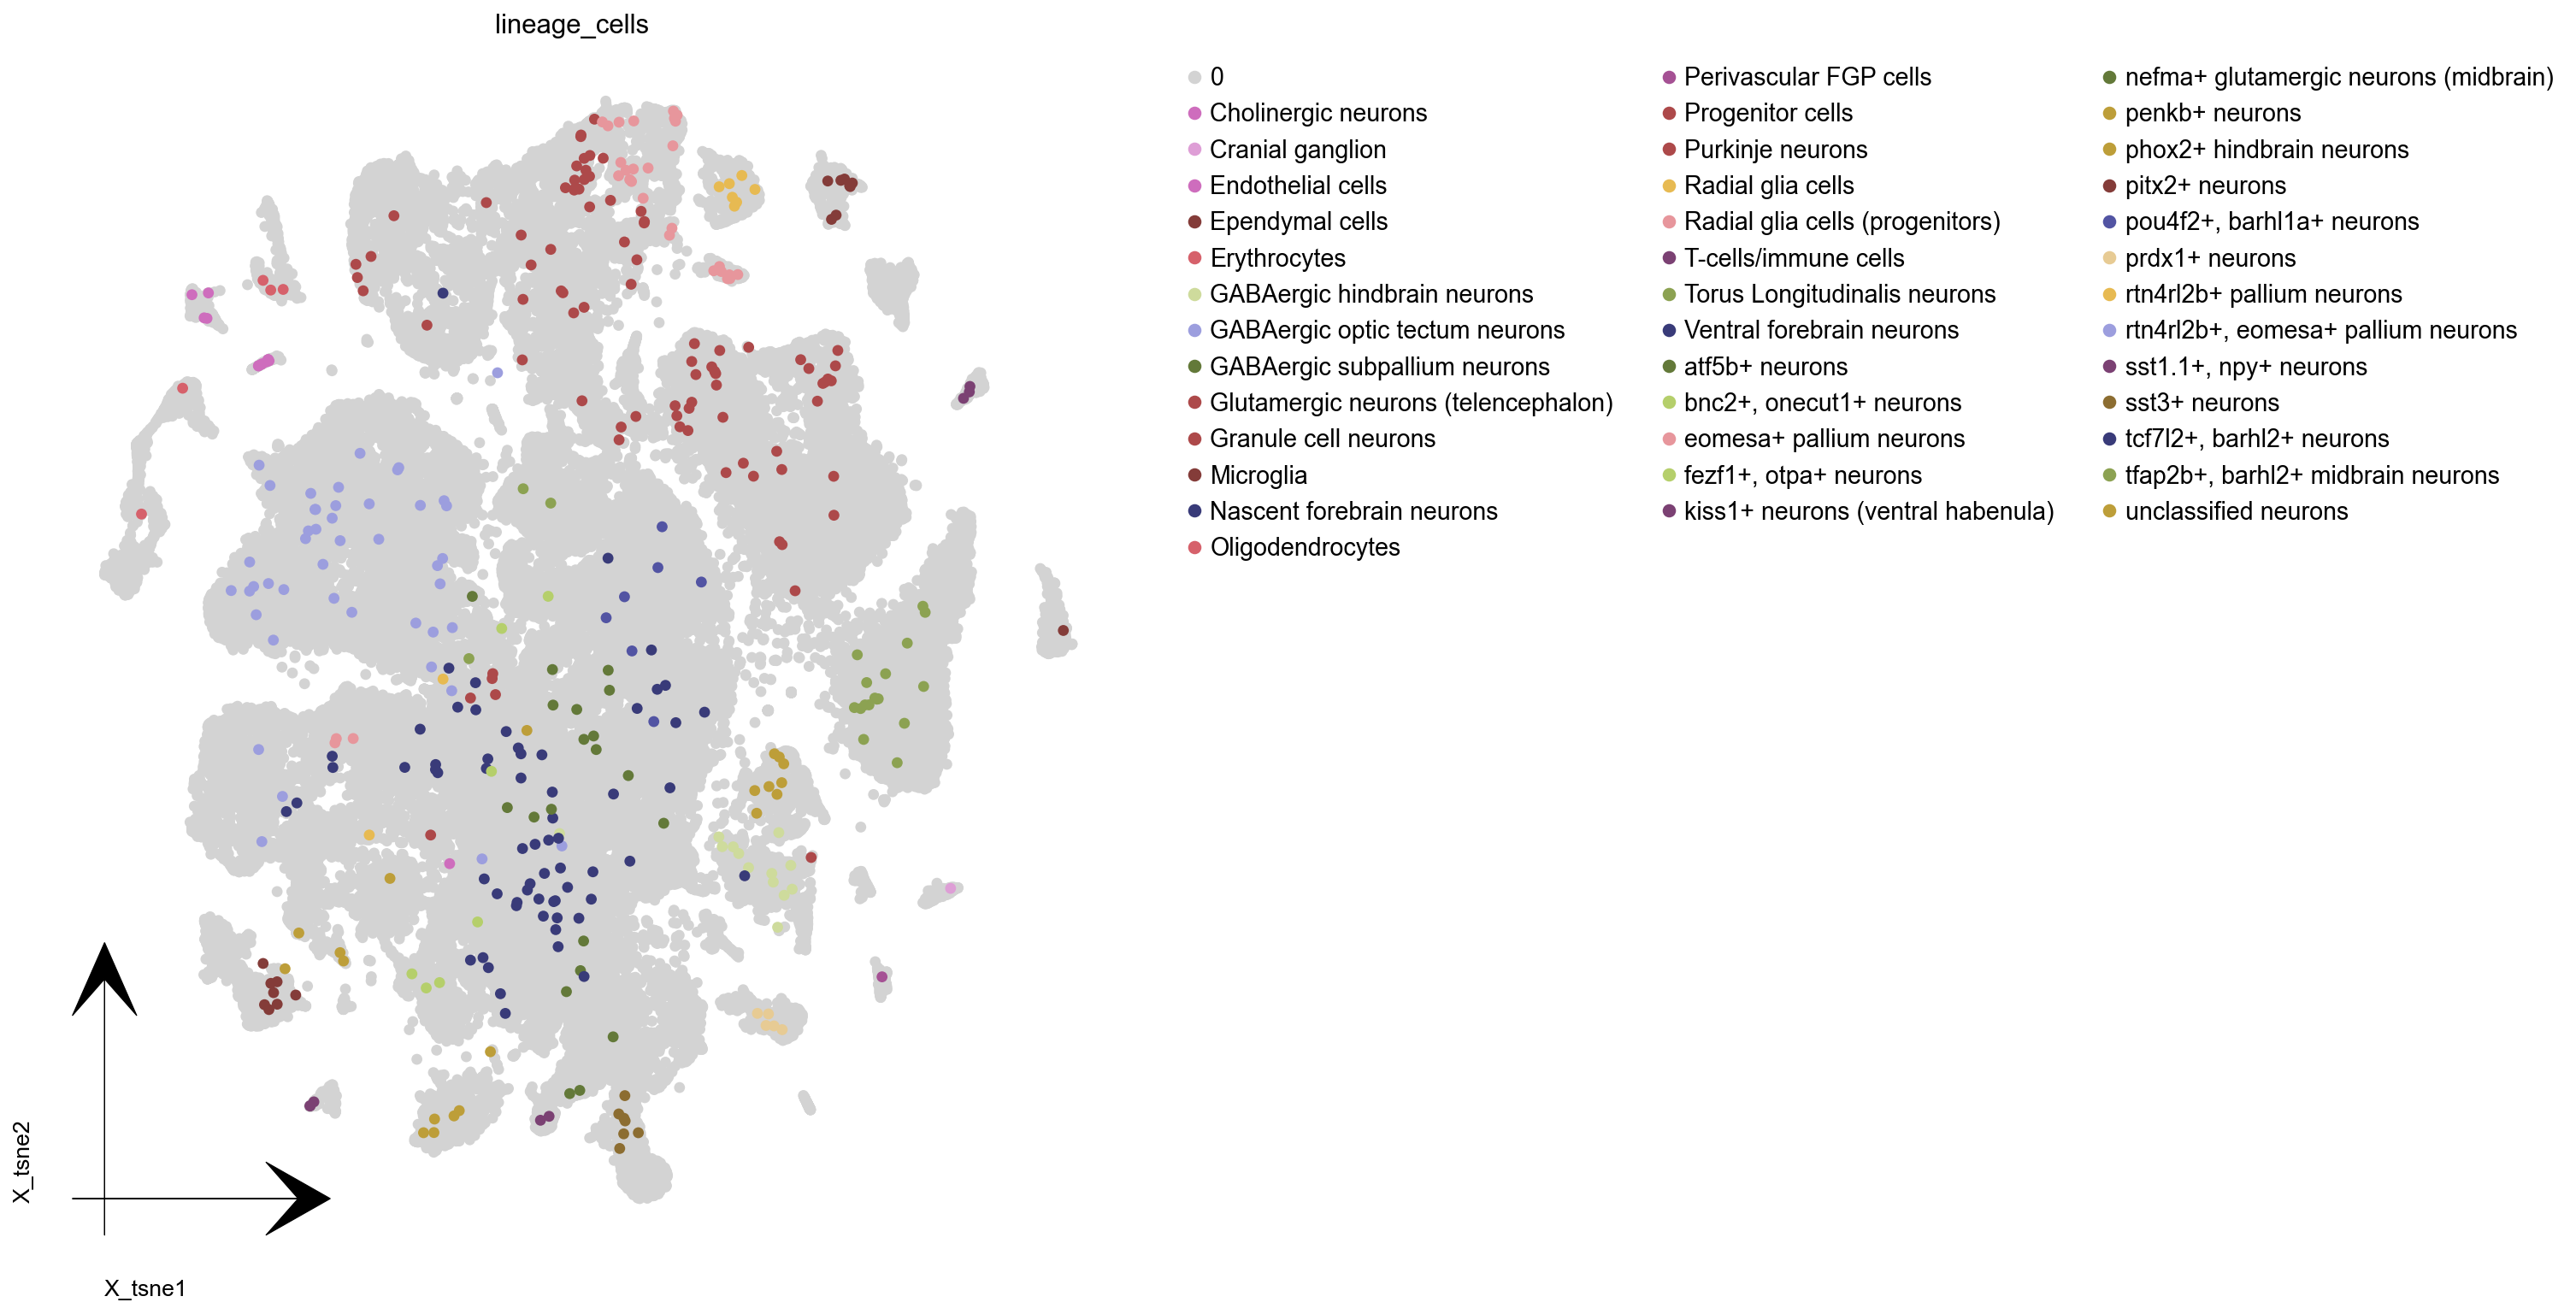

In [422]:
# Annotate cells with lineage data
adata = dyn.read('adata_temp.h5ad')
adata.obs = adata.obs.join(allele_table['cellBC'], how='left')

lineage_series = adata.obs['cell_type'].astype(str)
lineage_series[adata.obs['cellBC'].isna()] = '0'
adata.obs['lineage_cells'] = pd.Categorical(lineage_series)

adata = adata[adata.obs.sort_values('lineage_cells').index, :].copy()

dyn.pl.tsne(adata, 
            color='lineage_cells',
            color_key=color_key,
            figsize=(12, 12),
            show_legend='right',
            pointsize=0.5,
            alpha=1,
            sort='decreasing')

|-----------> plotting with basis key=X_tsne
|-----------> skip filtering lineage_cells by stack threshold when stacking color because it is not a numeric type


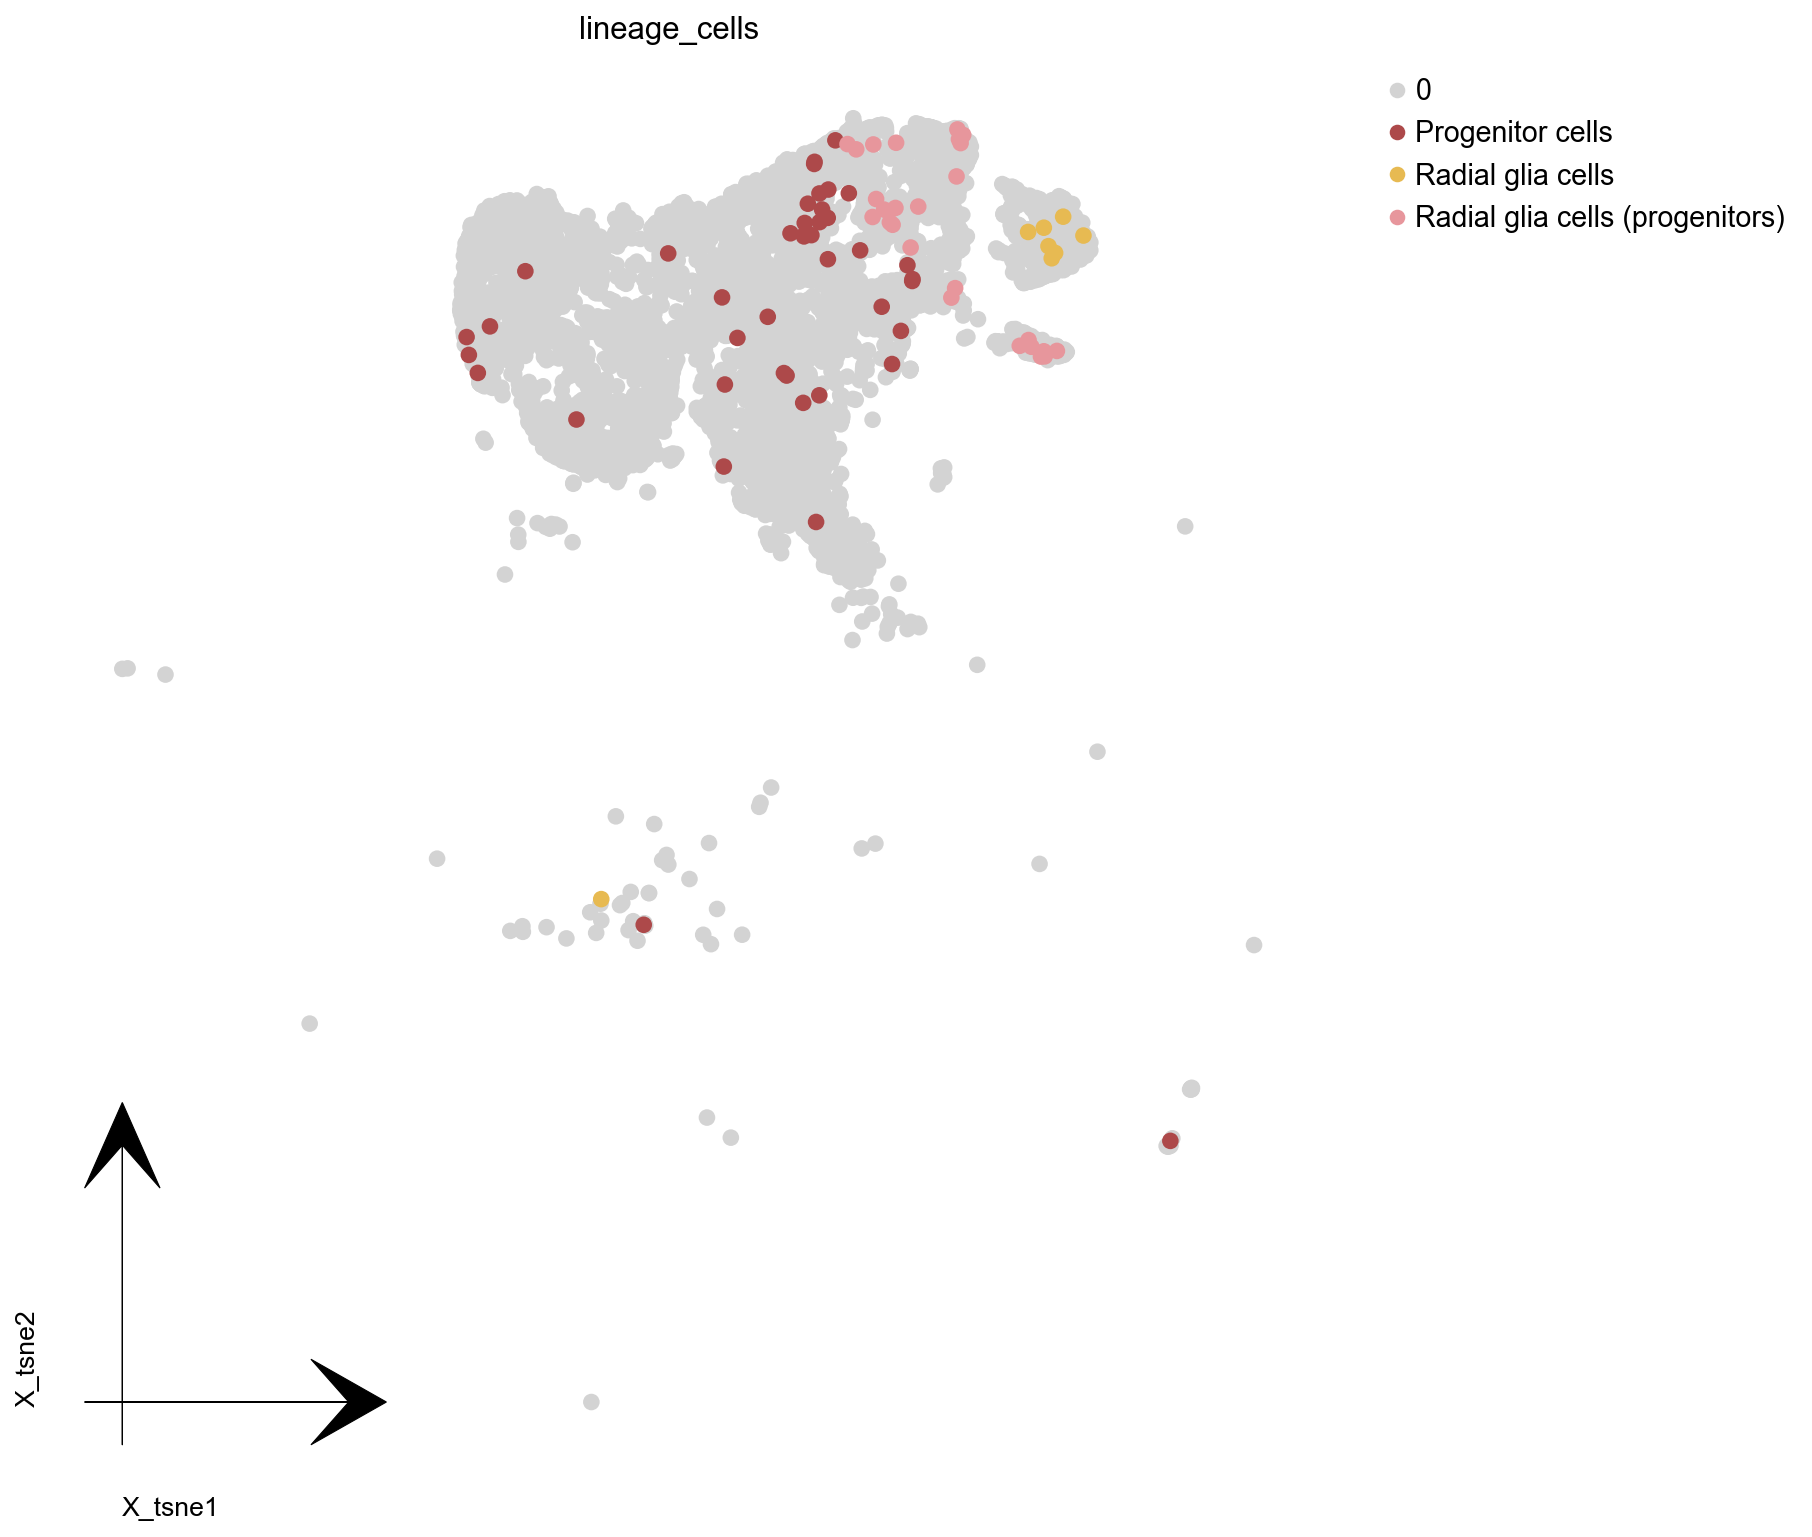

In [423]:
# Subset to progenitors only
prog = adata[adata.obs['cell_type'].isin(["Progenitor cells", "Radial glia cells (progenitors)", "Radial glia cells"]), :].copy()
prog.obs.sort_values('lineage_cells', inplace=True)
dyn.pl.tsne(prog, 
            color='lineage_cells',
            color_key=color_key,
            figsize=(12, 12),
            show_legend='right',
            pointsize=0.3,
            alpha=1,
            sort='decreasing')

In [ ]:
dyn.tl.neighbors(prog)

In [ ]:
root_cells = prog.obs.index[prog.obs['cell_type'] == 'Radial glia cells']
adata.uns['iroot'] = list(prog.obs_names).index(root_cells[0])

sc.tl.dpt(prog)

In [ ]:
dyn.pl.tsne(prog, color='dpt_pseudotime', 
            figsize=(10,12),pointsize=0.1,alpha=1)

In [ ]:
adata.layers['M_s']=adata.X
dyn.tl.pseudotime_velocity(adata,
                          pseudotime='palantir_pseudotime')